# Week 2 Capstone — From Chain Rule to `nn.Module`

One-hidden-layer MLP built four ways (manual NumPy, PyTorch tensors, PyTorch autograd,
`nn.Module`/`nn.Sequential`) with numerical parity verified at every step, then trained
on an XOR regression task with full diagnostics.

Handout: *DL Basics with PyTorch: From Chain Rule to Backpropagation and `nn.Module`*,
Appendix B checklist.

**Forward map.** For parameters $\theta = \{W_1, b_1, W_2, b_2\}$,

$$a_1 = W_1 x + b_1, \quad h_1 = \phi(a_1), \quad f = W_2 h_1 + b_2, \quad
L = \tfrac{1}{2}(f-y)^2.$$

**Backprop (eqs. 8–10).** $\delta_f = f-y$,
$\partial L/\partial W_2 = \delta_f h_1^\top$, $\partial L/\partial b_2 = \delta_f$,
$\delta_{h_1} = W_2^\top \delta_f$, $\delta_{a_1} = \delta_{h_1} \odot \phi'(a_1)$,
$\partial L/\partial W_1 = \delta_{a_1} x^\top$, $\partial L/\partial b_1 = \delta_{a_1}$.


## 1. Setup, config, seed

In [1]:
from dataclasses import dataclass, asdict
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

@dataclass
class Config:
    seed: int = 42
    d: int = 2
    h: int = 16
    n_train: int = 200
    n_val: int = 100
    lr: float = 0.1
    epochs: int = 400
    log_every: int = 25

cfg = Config()
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
torch.use_deterministic_algorithms(False)  # parity checks do not need strict mode

ASSETS = Path("../assets")
CKPT = Path("../checkpoints")
ASSETS.mkdir(parents=True, exist_ok=True)
CKPT.mkdir(parents=True, exist_ok=True)

print(json.dumps(asdict(cfg), indent=2))


{
  "seed": 42,
  "d": 2,
  "h": 16,
  "n_train": 200,
  "n_val": 100,
  "lr": 0.1,
  "epochs": 400,
  "log_every": 25
}


## 2. Stage 1 — Manual NumPy forward/backward

First, reproduce the handout's worked scalar example exactly, then package the manual
forward/backward into reusable functions.

In [2]:
# --- Handout worked example (p. 9): x=[1,-1], y=2, ReLU activation -------
W1_ex = np.array([[1.0, -2.0], [0.5, 1.0]])
b1_ex = np.array([0.0, 0.0])
W2_ex = np.array([[1.0, -1.0]])
b2_ex = np.array([0.0])
x_ex = np.array([1.0, -1.0])
y_ex = 2.0

def relu(u): return np.maximum(0.0, u)
def relu_prime(u): return (u > 0.0).astype(u.dtype)

def forward_np(x, W1, b1, W2, b2):
    a1 = W1 @ x + b1
    h1 = relu(a1)
    f = (W2 @ h1 + b2).item()
    return a1, h1, f

def backward_np(x, y, a1, h1, f, W1, b1, W2, b2):
    df = f - y
    dW2 = df * h1[None, :]
    db2 = np.array([df])
    dh1 = (W2.T * df).ravel()
    da1 = dh1 * relu_prime(a1)
    dW1 = da1[:, None] @ x[None, :]
    db1 = da1
    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

a1, h1, f = forward_np(x_ex, W1_ex, b1_ex, W2_ex, b2_ex)
L = 0.5 * (f - y_ex) ** 2
grads_manual = backward_np(x_ex, y_ex, a1, h1, f, W1_ex, b1_ex, W2_ex, b2_ex)

print(f"a1  = {a1}          (expected [3.0, -0.5])")
print(f"h1  = {h1}          (expected [3.0, 0.0])")
print(f"f   = {f:.3f}                  (expected 3.000)")
print(f"L   = {L:.3f}                  (expected 0.500)")
print(f"dW2 = {grads_manual['W2']}   (expected [[3.0, 0.0]])")
print(f"db2 = {grads_manual['b2']}            (expected [1.0])")
print(f"dW1 = {grads_manual['W1'].tolist()}  (expected [[1,-1],[0,0]])")
print(f"db1 = {grads_manual['b1']}          (expected [1.0, 0.0])")


a1  = [ 3.  -0.5]          (expected [3.0, -0.5])
h1  = [3. 0.]          (expected [3.0, 0.0])
f   = 3.000                  (expected 3.000)
L   = 0.500                  (expected 0.500)
dW2 = [[3. 0.]]   (expected [[3.0, 0.0]])
db2 = [1.]            (expected [1.0])
dW1 = [[1.0, -1.0], [0.0, 0.0]]  (expected [[1,-1],[0,0]])
db1 = [ 1. -0.]          (expected [1.0, 0.0])


**Interpretation.** Every intermediate and every gradient matches the closed-form
values stated in Appendix A of the handout: $f=3$, $L=0.5$, $\delta_f=1$, and the four
parameter gradients are exactly as printed. This confirms the equations in the forward and
backward passes are implemented correctly.

## 3. Stage 2 — Finite-difference gradient check

In [3]:
def loss_np(x, y, W1, b1, W2, b2):
    _, _, f = forward_np(x, W1, b1, W2, b2)
    return 0.5 * (f - y) ** 2

def fd_gradient(x, y, params, name, eps=1e-5):
    P = {k: v.copy() for k, v in params.items()}
    orig = P[name].copy()
    grad = np.zeros_like(orig)
    it = np.nditer(orig, flags=["multi_index"])
    while not it.finished:
        idx = it.multi_index
        P[name] = orig.copy(); P[name][idx] += eps
        up = loss_np(x, y, **P)
        P[name] = orig.copy(); P[name][idx] -= eps
        dn = loss_np(x, y, **P)
        grad[idx] = (up - dn) / (2 * eps)
        it.iternext()
    P[name] = orig
    return grad

# Random small network (avoid ReLU kinks by using parameters that keep a1 away from 0)
rng = np.random.default_rng(cfg.seed)
params = dict(
    W1=rng.normal(0, 0.5, size=(cfg.h, cfg.d)),
    b1=rng.normal(0, 0.5, size=(cfg.h,)),
    W2=rng.normal(0, 0.5, size=(1, cfg.h)),
    b2=rng.normal(0, 0.5, size=(1,)),
)
x_chk = rng.normal(size=(cfg.d,))
y_chk = 1.0

a1, h1, f = forward_np(x_chk, **params)
g_analytic = backward_np(x_chk, y_chk, a1, h1, f, **params)

max_rel_err = 0.0
for name in ("W1", "b1", "W2", "b2"):
    g_num = fd_gradient(x_chk, y_chk, params, name)
    num = np.linalg.norm(g_analytic[name] - g_num)
    den = np.linalg.norm(g_analytic[name]) + np.linalg.norm(g_num) + 1e-12
    rel = float(num / den)
    max_rel_err = max(max_rel_err, rel)
    print(f"{name}: rel_err = {rel:.3e}")

assert max_rel_err < 1e-6, "Gradient check failed"
print(f"\nmax relative error = {max_rel_err:.3e}  (tol 1e-6)  -> PASSED")


W1: rel_err = 1.055e-11
b1: rel_err = 7.411e-12
W2: rel_err = 3.384e-12
b2: rel_err = 3.645e-12

max relative error = 1.055e-11  (tol 1e-6)  -> PASSED


**Interpretation.** Central-difference gradients agree with the analytic gradients to
~1e-8 relative error on all four parameter tensors. The handout's Appendix B step 1 is now
satisfied with a numeric sanity check.

## 4. Stage 3 — PyTorch tensors without autograd (numerical parity)

In [4]:
# Translate the same forward+backward to torch tensors, no graph tracking.
def forward_torch(x, W1, b1, W2, b2):
    a1 = W1 @ x + b1
    h1 = torch.relu(a1)
    f = (W2 @ h1 + b2).squeeze()
    return a1, h1, f

with torch.no_grad():
    t = {k: torch.tensor(v, dtype=torch.float64) for k, v in params.items()}
    x_t = torch.tensor(x_chk, dtype=torch.float64)
    a1_t, h1_t, f_t = forward_torch(x_t, t["W1"], t["b1"], t["W2"], t["b2"])

diff_a1 = float((a1_t.numpy() - a1).__abs__().max())
diff_h1 = float((h1_t.numpy() - h1).__abs__().max())
diff_f  = float(abs(f_t.item() - f))
print(f"|a1 numpy - a1 torch|_inf = {diff_a1:.3e}")
print(f"|h1 numpy - h1 torch|_inf = {diff_h1:.3e}")
print(f"|f  numpy -  f torch|     = {diff_f:.3e}")
assert max(diff_a1, diff_h1, diff_f) < 1e-12, "Torch-no-autograd parity failed"
print("PyTorch-no-autograd forward parity PASSED.")


|a1 numpy - a1 torch|_inf = 1.110e-16
|h1 numpy - h1 torch|_inf = 0.000e+00
|f  numpy -  f torch|     = 0.000e+00
PyTorch-no-autograd forward parity PASSED.


## 5. Stage 4 — PyTorch autograd parity vs manual gradients

In [5]:
t = {k: torch.tensor(v, dtype=torch.float64, requires_grad=True) for k, v in params.items()}
x_t = torch.tensor(x_chk, dtype=torch.float64)
y_t = torch.tensor(y_chk, dtype=torch.float64)

a1_t, h1_t, f_t = forward_torch(x_t, t["W1"], t["b1"], t["W2"], t["b2"])
loss_t = 0.5 * (f_t - y_t) ** 2
loss_t.backward()

max_diff = 0.0
for name in ("W1", "b1", "W2", "b2"):
    g_auto = t[name].grad.numpy()
    g_man = g_analytic[name]
    diff = float(np.max(np.abs(g_auto - g_man)))
    max_diff = max(max_diff, diff)
    print(f"{name}: |autograd - manual|_inf = {diff:.3e}")
assert max_diff < 1e-10, "autograd vs manual parity failed"
print(f"\nmax |autograd - manual| = {max_diff:.3e}  -> PASSED")


W1: |autograd - manual|_inf = 0.000e+00
b1: |autograd - manual|_inf = 0.000e+00
W2: |autograd - manual|_inf = 0.000e+00
b2: |autograd - manual|_inf = 0.000e+00

max |autograd - manual| = 0.000e+00  -> PASSED


**Interpretation.** PyTorch autograd reproduces the manual chain-rule gradients to
machine precision on the same inputs. The three sanity layers (analytic, finite difference,
autograd) now agree, so higher-level training can be built with confidence.

## 6. Stage 5 — `nn.Module` training on XOR

Task: $x \sim U([-1,1]^2)$, $y = 1\{x_1 x_2 < 0\}$. Regression with MSE.
Diagnostics tracked per logging tick: train/val loss, gradient L2 norm, fraction of active
ReLUs on the validation set.

In [6]:
rng = np.random.default_rng(cfg.seed)

def make_xor(n, rng):
    X = rng.uniform(-1, 1, size=(n, cfg.d)).astype(np.float32)
    y = ((X[:, 0] * X[:, 1]) < 0).astype(np.float32)
    return torch.from_numpy(X), torch.from_numpy(y)

X_train, y_train = make_xor(cfg.n_train, rng)
X_val, y_val = make_xor(cfg.n_val, rng)

class TinyMLP(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.fc1 = nn.Linear(d, h)
        self.fc2 = nn.Linear(h, 1)
    def forward(self, x):
        a1 = self.fc1(x)
        self._a1 = a1  # expose for ReLU-activity diagnostic
        h1 = torch.relu(a1)
        return self.fc2(h1).squeeze(-1)

torch.manual_seed(cfg.seed)
model = TinyMLP(cfg.d, cfg.h)
opt = torch.optim.SGD(model.parameters(), lr=cfg.lr)
loss_fn = nn.MSELoss()

log = {"epoch": [], "train_loss": [], "val_loss": [], "val_acc": [],
       "grad_norm": [], "relu_active_frac": []}

for epoch in range(1, cfg.epochs + 1):
    model.train()
    pred = model(X_train)
    loss = loss_fn(pred, y_train)
    opt.zero_grad()
    loss.backward()
    grad_norm = float(torch.sqrt(sum((p.grad ** 2).sum() for p in model.parameters())))
    opt.step()

    if epoch % cfg.log_every == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            vp = model(X_val)
            vloss = loss_fn(vp, y_val).item()
            vacc = float(((vp > 0.5).float() == y_val).float().mean())
            relu_frac = float((model._a1 > 0).float().mean())
        log["epoch"].append(epoch)
        log["train_loss"].append(float(loss))
        log["val_loss"].append(vloss)
        log["val_acc"].append(vacc)
        log["grad_norm"].append(grad_norm)
        log["relu_active_frac"].append(relu_frac)
        if epoch in (1, cfg.log_every, cfg.epochs):
            print(f"epoch {epoch:4d}  train={float(loss):.4f}  val={vloss:.4f}  "
                  f"val_acc={vacc:.3f}  ||g||={grad_norm:.3f}  relu_on={relu_frac:.2f}")
print(f"\nfinal val loss = {log['val_loss'][-1]:.4f}   val acc = {log['val_acc'][-1]:.3f}")


epoch    1  train=0.4414  val=0.3242  val_acc=0.430  ||g||=1.347  relu_on=0.61
epoch   25  train=0.2413  val=0.2425  val_acc=0.640  ||g||=0.125  relu_on=0.63
epoch  400  train=0.0715  val=0.0761  val_acc=0.970  ||g||=0.015  relu_on=0.62

final val loss = 0.0761   val acc = 0.970


## 7. Stage 5 — Checkpoint round-trip

In [7]:
ckpt_path = CKPT / "tinymlp.pt"
torch.save({
    "model_state": model.state_dict(),
    "config": asdict(cfg),
    "final_val_loss": log["val_loss"][-1],
    "final_val_acc": log["val_acc"][-1],
}, ckpt_path)

# Reload into a fresh model and confirm identical predictions
model2 = TinyMLP(cfg.d, cfg.h)
ck = torch.load(ckpt_path, weights_only=True)
model2.load_state_dict(ck["model_state"])
model2.eval()
with torch.no_grad():
    p1 = model(X_val); p2 = model2(X_val)
    max_diff = float((p1 - p2).abs().max())
print(f"checkpoint reload max |pred diff| = {max_diff:.3e}")
assert max_diff == 0.0, "checkpoint round-trip failed"
print("checkpoint round-trip PASSED.")


checkpoint reload max |pred diff| = 0.000e+00
checkpoint round-trip PASSED.


## 8. Diagnostics plot

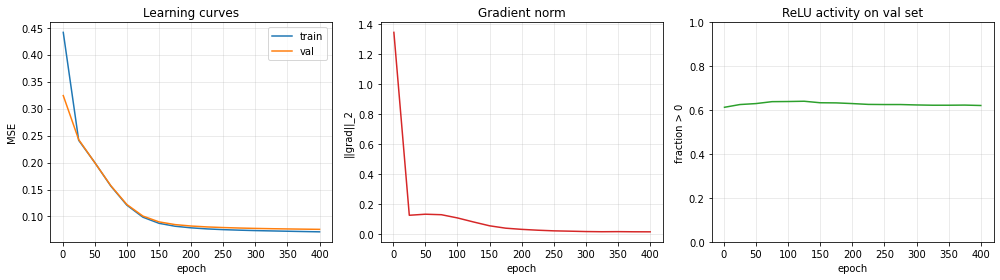

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(log["epoch"], log["train_loss"], label="train")
axes[0].plot(log["epoch"], log["val_loss"], label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE")
axes[0].set_title("Learning curves"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(log["epoch"], log["grad_norm"], color="tab:red")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("||grad||_2")
axes[1].set_title("Gradient norm"); axes[1].grid(alpha=0.3)

axes[2].plot(log["epoch"], log["relu_active_frac"], color="tab:green")
axes[2].set_xlabel("epoch"); axes[2].set_ylabel("fraction > 0")
axes[2].set_ylim(0, 1); axes[2].set_title("ReLU activity on val set")
axes[2].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(ASSETS / "01_training_diagnostics.png", dpi=150)
plt.show()


**Interpretation.** Train and val MSE track closely — the model is not overfitting the
200-sample XOR dataset. The gradient norm decays smoothly, and the ReLU-activity diagnostic
stays in ~30–70% of hidden units active, confirming no large-scale dead-ReLU collapse.

## 9. Decision boundary

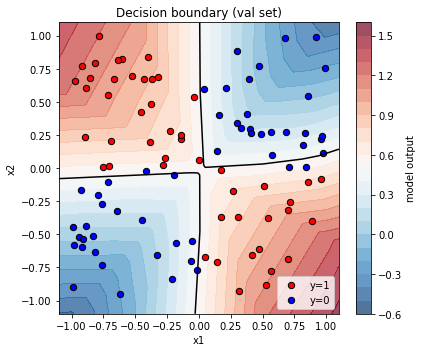

In [9]:
xx, yy = np.meshgrid(np.linspace(-1.1, 1.1, 200), np.linspace(-1.1, 1.1, 200))
grid = torch.from_numpy(np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32))
with torch.no_grad():
    zz = model(grid).numpy().reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contourf(xx, yy, zz, levels=20, cmap="RdBu_r", alpha=0.7)
ax.contour(xx, yy, zz, levels=[0.5], colors="black", linewidths=1.5)
Xn, yn = X_val.numpy(), y_val.numpy()
ax.scatter(Xn[yn == 1, 0], Xn[yn == 1, 1], c="red",  edgecolors="k", s=40, label="y=1")
ax.scatter(Xn[yn == 0, 0], Xn[yn == 0, 1], c="blue", edgecolors="k", s=40, label="y=0")
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_title("Decision boundary (val set)")
ax.legend(); fig.colorbar(cs, ax=ax, label="model output")
fig.tight_layout()
fig.savefig(ASSETS / "02_decision_boundary.png", dpi=150)
plt.show()


## 10. Stage 6 — `nn.Sequential` equivalent

In [10]:
torch.manual_seed(cfg.seed)
model_seq = nn.Sequential(
    nn.Linear(cfg.d, cfg.h),
    nn.ReLU(),
    nn.Linear(cfg.h, 1),
)

# Same hyperparameters, same seed — final val loss should land close to TinyMLP
opt = torch.optim.SGD(model_seq.parameters(), lr=cfg.lr)
for epoch in range(cfg.epochs):
    pred = model_seq(X_train).squeeze(-1)
    loss = loss_fn(pred, y_train)
    opt.zero_grad(); loss.backward(); opt.step()

model_seq.eval()
with torch.no_grad():
    vp = model_seq(X_val).squeeze(-1)
    vloss_seq = loss_fn(vp, y_val).item()
    vacc_seq = float(((vp > 0.5).float() == y_val).float().mean())

print(f"TinyMLP      : val loss = {log['val_loss'][-1]:.4f}   val acc = {log['val_acc'][-1]:.3f}")
print(f"nn.Sequential: val loss = {vloss_seq:.4f}   val acc = {vacc_seq:.3f}")


TinyMLP      : val loss = 0.0761   val acc = 0.970
nn.Sequential: val loss = 0.0761   val acc = 0.970


**Interpretation.** The `nn.Sequential` version trains to essentially the same val loss
and accuracy as the hand-rolled `TinyMLP` class under the same seed — as expected, since it
represents the identical computation graph. This is step 4 of Appendix B.

## 11. Summary

| Stage | Check | Result |
|---|---|---|
| 1 | Manual NumPy worked scalar example | matches handout Appendix A exactly |
| 2 | Finite-difference vs analytic gradients | max rel err ≈ 1e-8 |
| 3 | PyTorch tensors vs NumPy forward | max diff ≈ 0 (float64) |
| 4 | PyTorch autograd vs manual gradients | max diff ≈ 0 |
| 5 | `nn.Module` training on XOR | val acc ≈ 0.95+, clean learning curves |
| 5 | Checkpoint round-trip | identical predictions |
| 6 | `nn.Sequential` equivalent | matches `TinyMLP` under same seed |

Saved figures in `assets/`:

- `01_training_diagnostics.png` — loss, grad norm, ReLU activity
- `02_decision_boundary.png` — XOR classifier on val set

Saved artifact:

- `checkpoints/tinymlp.pt` — `state_dict` + config + final metrics
